# Notebook Dedicated to study the first candidates of 2p2PPO Data (above 5 MeV Cut)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import glob

# Load Data

In [3]:
# ------- Observable list -------
obs_list = ['energy_corrected', 'posr_av', 'posx', 'posy', 'posz_av', 'runID', 'itr']

# ------- Observable Dictionary -------
obs_dict = {obs: np.array([]) for obs in obs_list}

# ------- Directory of data -------
#main_dir = 'E:/Data/solars/solarnu_Realdata/bisMSB/first_candidates/analysis*/resume_files/'
main_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/resume_files/'
#main_dir = '/content/drive/MyDrive/SNO+ Analysis/data/solar_data/real_data/bis_MSB/Analysis*/resume_files/'
#main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/analysis*/resume_files/'

# Loop over the observable list to load the data in obs_dict

for obs in obs_list:
    obs_dir_list = glob.glob(main_dir + obs + '.npy') # List of directories where the obs is

    # Now loop over the list of directories
    for fdir in obs_dir_list:
        obs_i = np.load(fdir)

        #Save the loaded numpy array in the corresponding key observable in the observable dictioary
        obs_dict[obs] = np.append(obs_dict[obs], obs_i)


energy = obs_dict['energy_corrected']
posr_av = obs_dict['posr_av']
posx = obs_dict['posx']
posy = obs_dict['posy']
posz = obs_dict['posz_av']
runID = obs_dict['runID']
itr = obs_dict['itr']

# ======= Cut =======
en_cut = (energy >= 5)

cut_condition = en_cut

energy = energy[cut_condition]
posr_av = posr_av[cut_condition]
posx = posx[cut_condition]
posy = posy[cut_condition]
posz = posz[cut_condition]
runID = runID[cut_condition]
itr = itr[cut_condition]

In [4]:
energy

array([ 7.96696823,  5.20769378,  5.21273344,  5.89957287,  5.7292793 ,
        5.55190368,  7.12359934,  5.52659174,  5.11249708,  6.80309292,
        7.03829258,  5.27111471,  7.18792418,  5.91585313,  6.07945748,
        5.68704206,  5.98499675,  6.52562854,  5.49634773,  5.4497519 ,
        6.82476848,  5.22170916,  8.13693565,  6.16205349,  6.20751004,
        6.49830577,  6.19042402,  6.54925056,  6.82996153,  6.99837813,
        6.45935683,  5.20161596,  5.723007  ,  6.62023827,  7.88985161,
        5.52879174,  8.60518385,  5.50427999,  5.9942107 ,  7.87277634,
        7.51583949,  6.71916946,  8.26086264,  8.12077973,  8.46356055,
        6.14168406,  5.3855378 ,  7.81843857,  8.68175344,  5.9269634 ,
        5.71646603,  8.69902426,  6.05231141,  5.56115829,  5.54601741,
        7.4556572 ,  9.02286942,  5.94081994,  6.28395351,  5.12315469,
        6.21772868,  6.12915468,  6.02335507,  5.11355482,  5.22246736,
        6.76083341,  7.55162049,  5.95028777,  9.55557952,  6.08

# Plots of Observables

## Energy

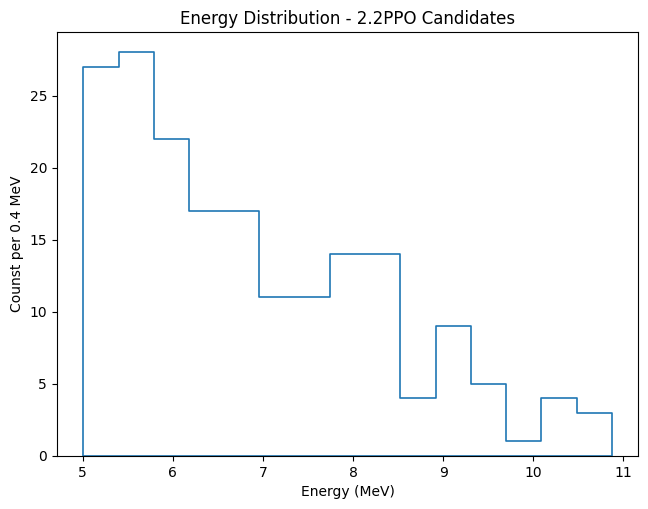

In [17]:
binwidth = 0.4

plt.figure(figsize = (7.5, 5.5))
sn.histplot(energy, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel('Energy (MeV)')
plt.ylabel(f'Counst per {binwidth} MeV')

plt.title('Energy Distribution - 2.2PPO Candidates')

plt.show()

## pos_r

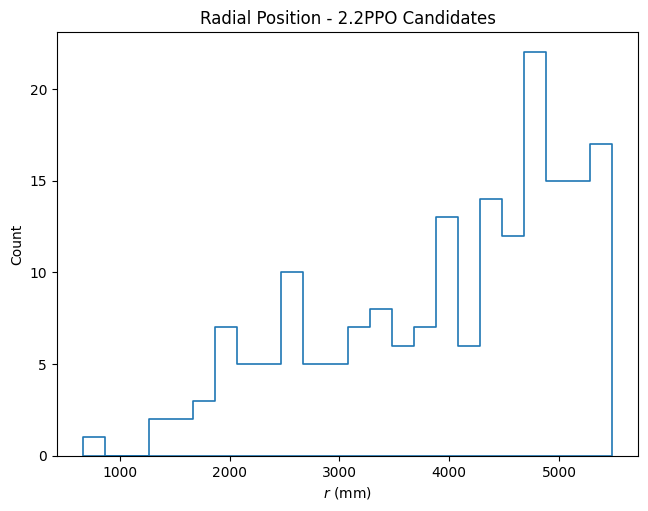

In [16]:
binwidth = 200

plt.figure(figsize = (7.5, 5.5))
sn.histplot(posr_av, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$r$ (mm)')

plt.title('Radial Position - 2.2PPO Candidates')

plt.show()

## Norm. Pos_r

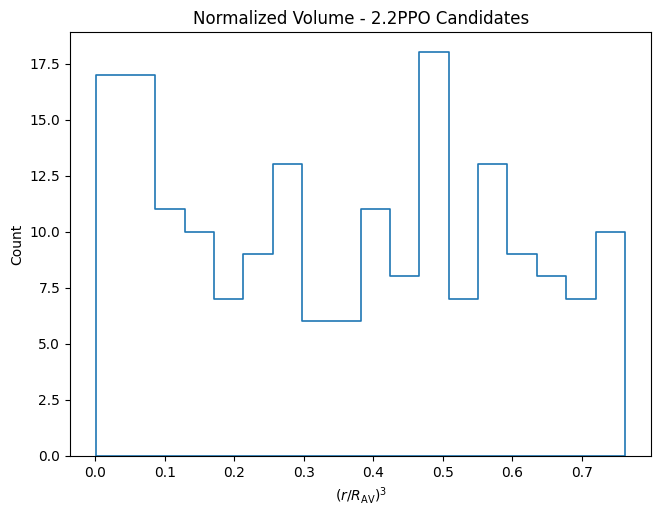

In [15]:
R_cut = 6000
norm_vol = (posr_av**3)/(R_cut**3)

bins = 18

plt.figure(figsize = (7.5, 5.5))
sn.histplot(norm_vol, bins = bins, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$(r/R_\text{AV})^3$')

plt.title('Normalized Volume - 2.2PPO Candidates')

plt.show()

## rho^2

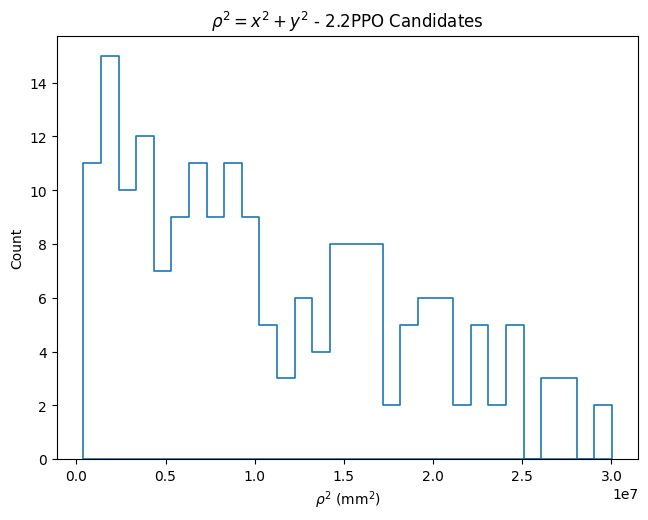

In [14]:
rho_sqr = (posx**2) + (posy**2)

binwidth = 1000**2

plt.figure(figsize = (7.5, 5.5))
sn.histplot(rho_sqr, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$\rho^2$ (mm$^2$)')

plt.title(r'$\rho^2 = x^2 + y^2$ - 2.2PPO Candidates')

plt.show()

## x vs. y

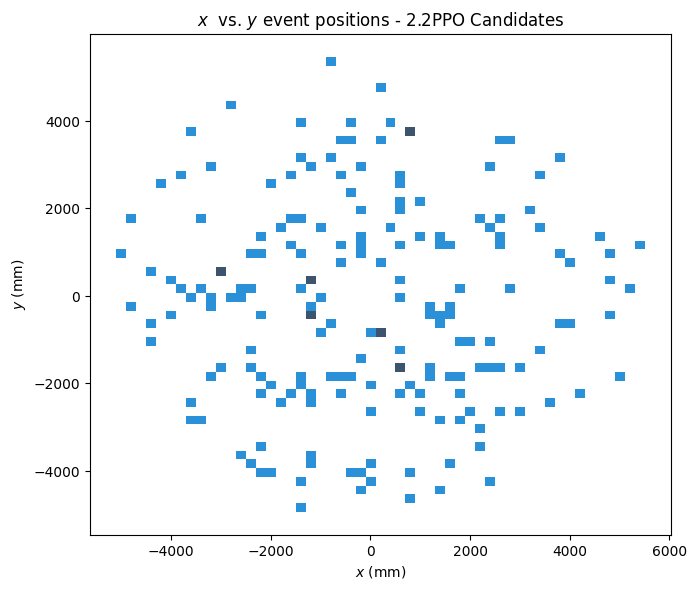

In [13]:
binwidth_x = 200
binwidth_y = 200

plt.figure(figsize = (7.5, 6.5))
sn.histplot(x = posx, y = posy, binwidth = (binwidth_x, binwidth_y))

plt.xlabel(r'$x$ (mm)')
plt.ylabel('$y$ (mm)')

plt.title(r'$x$  vs. $y$ event positions - 2.2PPO Candidates')

plt.show()

## z vs. rho^2

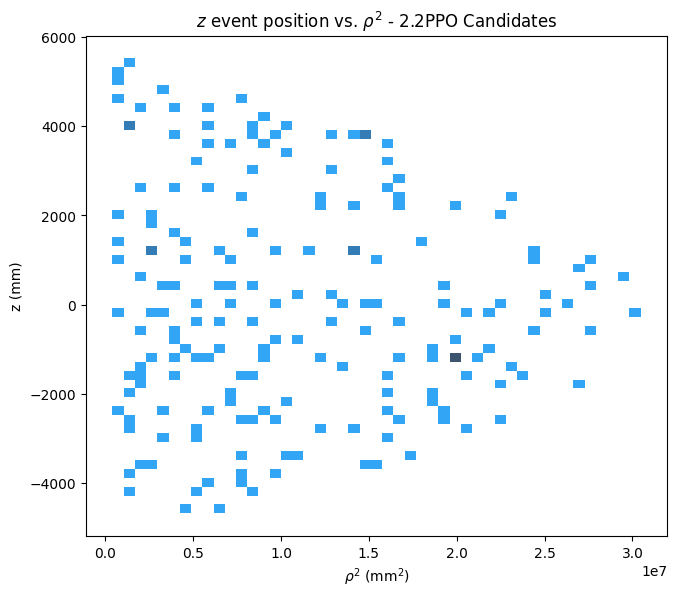

In [18]:
rho_sqr = (posx**2) + (posy**2)

binwidth_z = 200
binwidth_rho_sqr = 800**2

plt.figure(figsize = (7.5, 6.5))
sn.histplot(x = rho_sqr, y = posz, binwidth = (binwidth_rho_sqr, binwidth_z))

plt.xlabel(r'$\rho^2$ (mm$^2$)')
plt.ylabel('z (mm)')

plt.title(r'$z$ event position vs. $\rho^2$ - 2.2PPO Candidates')

plt.show()

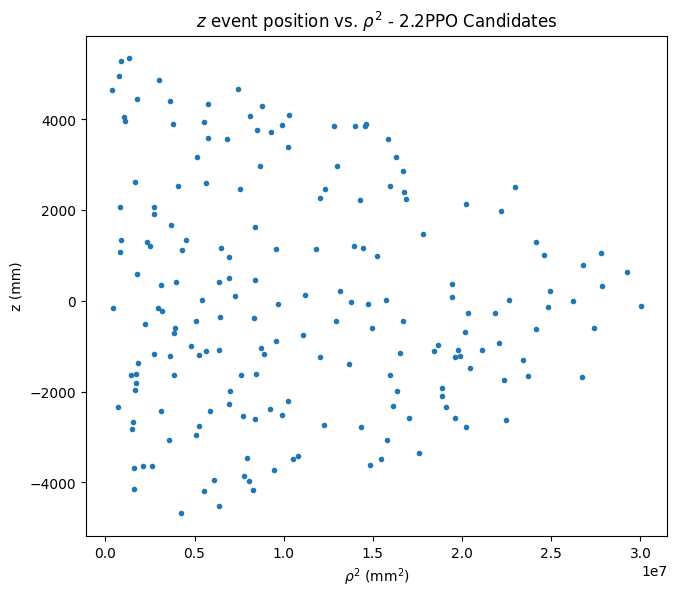

In [19]:
plt.figure(figsize = (7.5, 6.5))
plt.scatter(x = rho_sqr, y = posz, marker = '.')

plt.xlabel(r'$\rho^2$ (mm$^2$)')
plt.ylabel('z (mm)')

plt.title(r'$z$ event position vs. $\rho^2$ - 2.2PPO Candidates')

plt.show()

## Energy vs. r

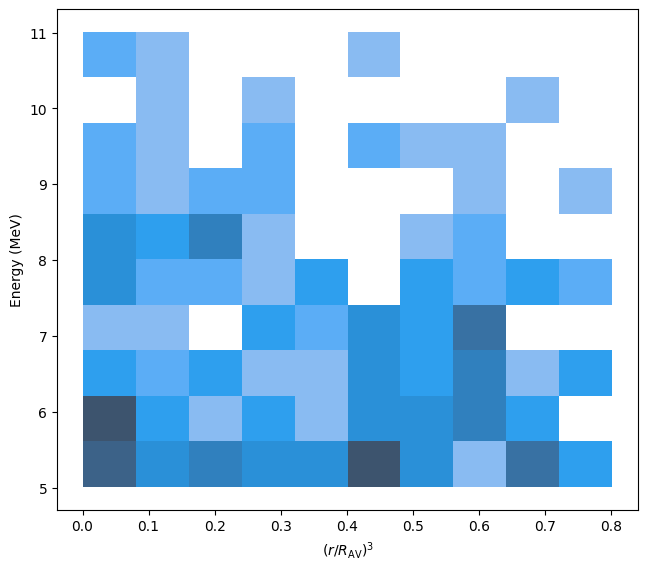

In [23]:
plt.figure(figsize = (7.5, 6.5))

binwidth_energy = 0.6
binwidth_posr = 0.08

sn.histplot(x = norm_vol, y = energy, binwidth = (binwidth_posr, binwidth_energy))

plt.xlabel(r'$(r/R_\text{AV})^3$')
plt.ylabel('Energy (MeV)')

plt.show()

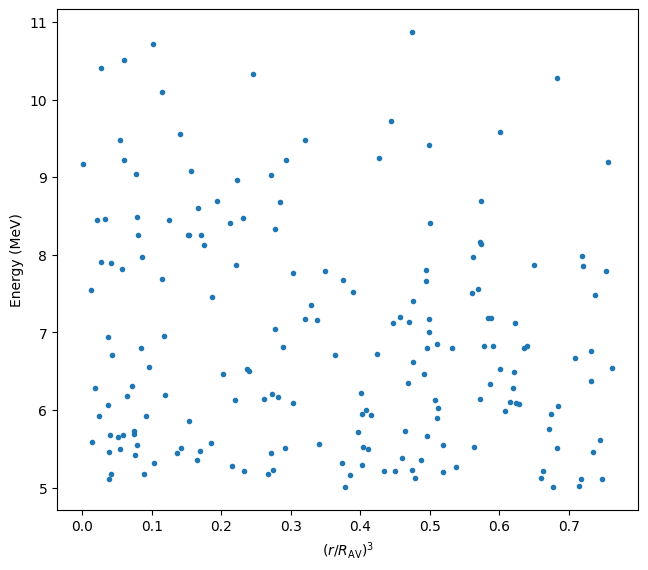

In [24]:
plt.figure(figsize = (7.5, 6.5))

binwidth_energy = 0.5
binwidth_posr = 0.08

plt.scatter(x = norm_vol, y = energy, marker = '.')

plt.xlabel(r'$(r/R_\text{AV})^3$')
plt.ylabel('Energy (MeV)')

plt.show()

## ITR

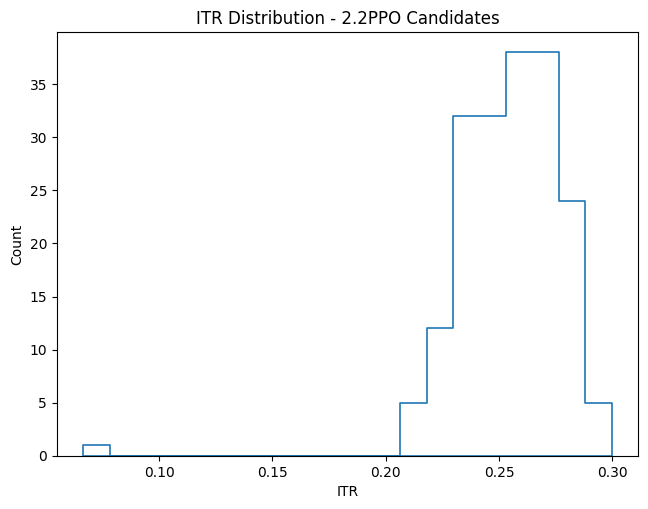

In [20]:
bins = 20

plt.figure(figsize = (7.5, 5.5))
sn.histplot(itr, bins = bins, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel('ITR')
#plt.ylabel(f'Counst per {binwidth} MeV')

plt.title('ITR Distribution - 2.2PPO Candidates')

plt.show()

In [23]:

t_res_cut_list = [(-5,5), (-5,4), (-5,3), (-5,2), (-5,1)]
hist_data = {tres: np.zeros(bins) for tres in t_res_cut_list}
hist_data

{(-5,
  5): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 (-5,
  4): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 (-5,
  3): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 (-5,
  2): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 (-5,
  1): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.])}

In [24]:
hist_data[t_res_cut_list[0]]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])